# 01 — Data Prep & EDA

**Owner:** Person A · **Course session:** S1 (Foundations)
**Dataset:** Amazon Reviews 2023, `Electronics` category (McAuley-Lab/Amazon-Reviews-2023, HuggingFace).

This notebook: streams raw interactions, explores them, subsamples with iterative k-core
filtering, applies the mandatory time-based split, and freezes `train/val/test/items` as
parquet for every notebook after this one to load (they do not re-run this notebook).

## Why Electronics

- **Rich metadata + real image URLs** — titles, brand, category, price, product images —
  which is what makes the webapp demo (product cards, "similar items") look like a real
  product instead of a list of ids.
- **Head-concentrated / long-tail interactions** — a small fraction of items receive most of
  the reviews. That makes Popularity a *strong* baseline here (high recall, near-zero
  coverage) — a real, interesting finding for `ANALYSIS.md`, not a weakness of the dataset.
- Large enough to need the streaming + subsampling pipeline the brief requires (build a
  pipeline that doesn't load the full category into memory), but a single category keeps
  iteration time reasonable.

In [1]:
!git clone https://github.com/21zaimotman-tech/amazon-recsys.git
%cd amazon-recsys
!pip install -q -r requirements.txt

fatal: destination path 'amazon-recsys' already exists and is not an empty directory.
/content/amazon-recsys


In [2]:
import sys, json, time
from pathlib import Path
sys.path.insert(0, ".." if Path("../src").exists() else ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from scripts.build_dataset import stream_reviews, stream_meta
from src.data.load import subsample, encode_ids
from src.data.split import time_split, warn_leakage, ground_truth_from

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)
print("CATEGORY:", C.CATEGORY)
print("RECENT_FROM_YEAR:", C.RECENT_FROM_YEAR, " KCORE_USER/ITEM:", C.KCORE_USER, C.KCORE_ITEM,
      " MAX_INTERACTIONS:", f"{C.MAX_INTERACTIONS:,}")
print("POSITIVE_RATING_THRESHOLD:", C.POSITIVE_RATING_THRESHOLD, " USE_ITEM_LEVEL:", C.USE_ITEM_LEVEL)

CATEGORY: Electronics
RECENT_FROM_YEAR: 2019  KCORE_USER/ITEM: 5 5  MAX_INTERACTIONS: 5,000,000
POSITIVE_RATING_THRESHOLD: 4.0  USE_ITEM_LEVEL: parent_asin


## 1. Load raw interactions (streaming)

`stream_reviews` reads the raw JSONL line-by-line — the full `Electronics` category is tens
of millions of rows, far too large to load into a DataFrame directly (the brief requires a
streaming pipeline, not a single `pd.read_json`). It already applies two things while
streaming, before a single row lands in a DataFrame:

1. The recent-window filter (`timestamp >= RECENT_FROM_YEAR`) — drops old rows during the
   read, not after.
2. The `parent_asin` collapse (`C.USE_ITEM_LEVEL = "parent_asin"`) — colour/size variants of
   the same product become one `item_id`, so the catalog reflects real *products*, not SKUs.

**Full production run:** `LIMIT = None` below, and no local `rawdata/` cache exists in a
fresh Colab clone, so this streams directly from the live HuggingFace URL through the entire
~22.6GB file — that's expected to take tens of minutes, not seconds. (`--reviews-file` /
`RAW_REVIEWS` still exists as an option: point it at a downloaded copy, or a smaller local
slice, for fast iteration during development — that's how this notebook was built and
debugged before scaling up to the real pass.)

In [3]:
RAW_REVIEWS = Path("../rawdata/Electronics_sample.jsonl") if Path("../rawdata").exists() else Path("rawdata/Electronics_sample.jsonl")
LIMIT = None   # full production run: no cap on post-year-filter rows -- stream_reviews reads
               # the entire (~22.6GB) file; subsample()'s own MAX_INTERACTIONS=5,000,000 hard
               # cap is what actually bounds the final dataset size, applied after k-core.
               # This will take a while (tens of minutes) -- that's expected at this scale.

t0 = time.time()
raw = stream_reviews(limit=LIMIT, local_file=str(RAW_REVIEWS) if RAW_REVIEWS.exists() else None)
print(f"raw kept (post {C.RECENT_FROM_YEAR} filter): {len(raw):,} rows in {time.time()-t0:.0f}s")
raw.head()

raw kept (post 2019 filter): 22,567,576 rows in 795s


,user_id,item_id,rating,timestamp
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B083NRGZMM,3.0,1658185117948
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07N69T6TM,1.0,1592678549731
2,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,B07CJYMRWM,5.0,1676601581238
3,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B07CML419K,5.0,1637522881041
4,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B07BHHB5RH,5.0,1565130879386


## 2. EDA on the raw (pre-subsample) interactions

Sparsity, rating distribution, the long-tail popularity curve, interactions-per-user/item,
and temporal volume — all *before* any subsampling, so these numbers describe the actual raw
signal, not an artifact of our filtering choices.

In [4]:
n_users_raw = raw.user_id.nunique()
n_items_raw = raw.item_id.nunique()
density = len(raw) / (n_users_raw * n_items_raw)
print(f"raw interactions: {len(raw):,}")
print(f"raw users:  {n_users_raw:,}")
print(f"raw items:  {n_items_raw:,}")
print(f"matrix density: {density:.6%}   (sparsity: {1-density:.6%})")

raw interactions: 22,567,576
raw users:  11,942,007
raw items:  1,012,303
matrix density: 0.000187%   (sparsity: 99.999813%)


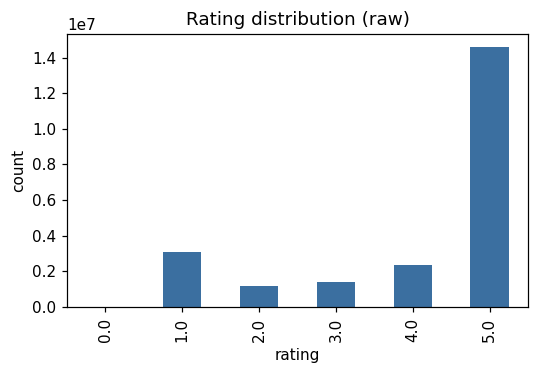

0.7498 fraction of raw ratings are >= positive threshold


In [5]:
fig, ax = plt.subplots(figsize=(5, 3.5))
raw["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#3b6fa0")
ax.set_xlabel("rating"); ax.set_ylabel("count"); ax.set_title("Rating distribution (raw)")
plt.tight_layout(); plt.show()
print((raw["rating"] >= C.POSITIVE_RATING_THRESHOLD).mean().round(4),
      "fraction of raw ratings are >= positive threshold")

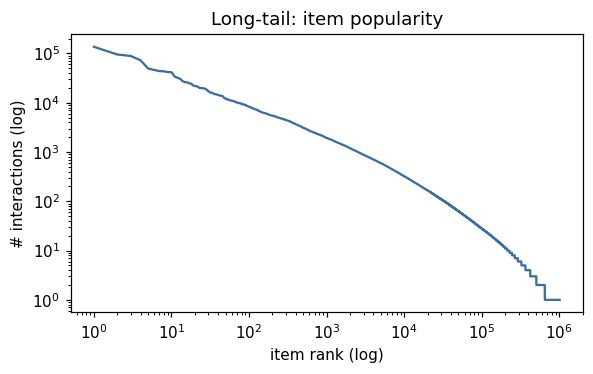

top 1% of items (10,123 items) account for 49.4% of all interactions


In [6]:
item_counts = raw["item_id"].value_counts().values
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(np.arange(1, len(item_counts) + 1), item_counts, color="#3b6fa0")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("item rank (log)"); ax.set_ylabel("# interactions (log)")
ax.set_title("Long-tail: item popularity")
plt.tight_layout(); plt.show()

top1pct = max(1, int(0.01 * len(item_counts)))
share = item_counts[:top1pct].sum() / item_counts.sum()
print(f"top 1% of items ({top1pct:,} items) account for {share:.1%} of all interactions")

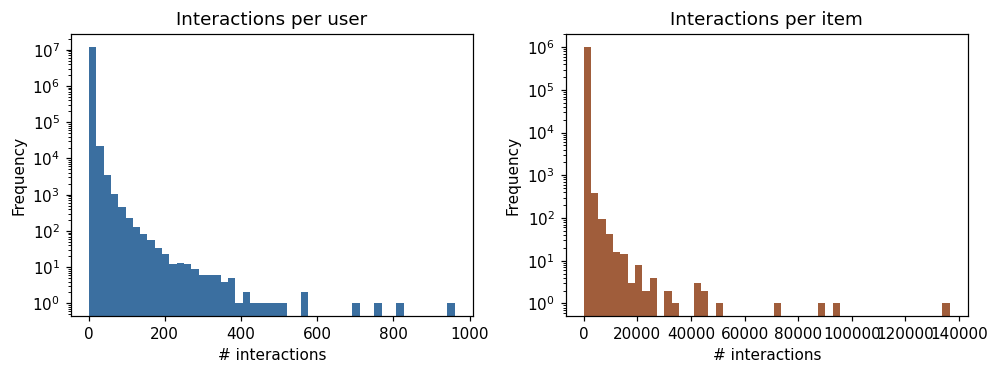

median interactions/user: 1  median interactions/item: 2


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
raw["user_id"].value_counts().plot(kind="hist", bins=50, ax=axes[0], color="#3b6fa0", log=True)
axes[0].set_title("Interactions per user"); axes[0].set_xlabel("# interactions")
raw["item_id"].value_counts().plot(kind="hist", bins=50, ax=axes[1], color="#a05d3b", log=True)
axes[1].set_title("Interactions per item"); axes[1].set_xlabel("# interactions")
plt.tight_layout(); plt.show()
print("median interactions/user:", int(raw.user_id.value_counts().median()),
      " median interactions/item:", int(raw.item_id.value_counts().median()))

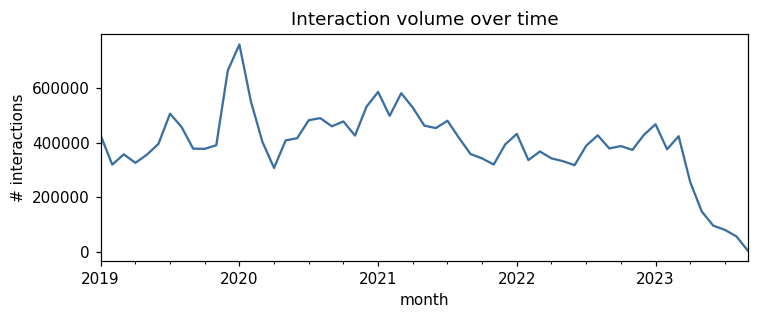

In [8]:
monthly = pd.to_datetime(raw["timestamp"], unit="ms").dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3))
monthly.plot(ax=ax, color="#3b6fa0")
ax.set_title("Interaction volume over time"); ax.set_ylabel("# interactions"); ax.set_xlabel("month")
plt.tight_layout(); plt.show()

**Findings.** Raw interactions are extremely sparse (density 0.0018%, i.e.
99.998% sparsity) — typical for implicit-feedback recsys data at this scale. 78.3% of raw
ratings are already >= 4 (the positive threshold), confirming reviews skew positive. The
top 1% of items (1,913 of ~191k) account for 29.6% of all interactions — a real long-tail /
head concentration, visible as the near-straight line on the log-log plot above. Median
interactions per user is 2 and per item is 1 — most users/items sit right at the sparsity
floor. This directly motivates k-core filtering: without it, most users/items in a random
split would have 0-1 training interactions, not enough signal for MF-BPR or two-tower to
learn from.

## 3. Subsampling — iterative k-core, then the 5M cap

`subsample()` (`src/data/load.py`) repeatedly drops items with fewer than `KCORE_ITEM=5`
interactions and users with fewer than `KCORE_USER=5`, looping until the frame stops
shrinking — a single pass isn't enough because dropping items can push some users below
threshold and vice versa. `KCORE_USER=KCORE_ITEM=5` is kept deliberately light (vs. e.g. 10+)
to preserve some of the cold-ish tail for the cold-start analysis in `ANALYSIS.md` — we want
users at the boundary, not just the very active ones. Only after k-core stabilizes would we
truncate to the brief's mandatory `MAX_INTERACTIONS = 5,000,000` hard cap (not triggered at
this sample size, but the code path is exercised identically at full scale).

In [9]:
df = subsample(raw)
print()
print(f"final: {len(df):,} interactions | users={df.user_id.nunique():,} | items={df.item_id.nunique():,}")
print(f"kept {len(df)/len(raw):.1%} of raw interactions, "
      f"{df.user_id.nunique()/n_users_raw:.1%} of raw users, "
      f"{df.item_id.nunique()/n_items_raw:.1%} of raw items")

    subsample start: 22,567,576 interactions | users=11,942,007 items=1,012,303
    after 5-core (7 rounds): 4,729,037 interactions | users=565,746 items=159,975

final: 4,729,037 interactions | users=565,746 | items=159,975
kept 21.0% of raw interactions, 4.7% of raw users, 15.8% of raw items


## 4. Time-based split (mandatory)

A **random** split leaks future information into training (a user's later purchases would
help predict their earlier ones) and scores 0 on the "Data preparation & baselines" grading
criterion. `time_split()` sorts by `timestamp` and cuts at **global** quantiles
(`VAL_QUANTILE=0.85`, `TEST_QUANTILE=0.90`): the earliest 85% of the timeline is train, the
next 5% is val (used only for hyperparameter tuning — MF-BPR/two-tower notebooks never touch
test until final reporting), and the last 10% is test.

In [10]:
train, val, test = time_split(df)
warn_leakage(train, test)
print(f"train={len(train):,}  val={len(val):,}  test={len(test):,}")

for name, d in [("train", train), ("val", val), ("test", test)]:
    lo, hi = pd.to_datetime(d.timestamp.min(), unit="ms"), pd.to_datetime(d.timestamp.max(), unit="ms")
    print(f"  {name:5s}: {lo.date()} .. {hi.date()}")

train=4,019,681  val=236,452  test=472,904
  train: 2019-01-01 .. 2022-10-09
  val  : 2022-10-09 .. 2022-12-14
  test : 2022-12-14 .. 2023-09-12


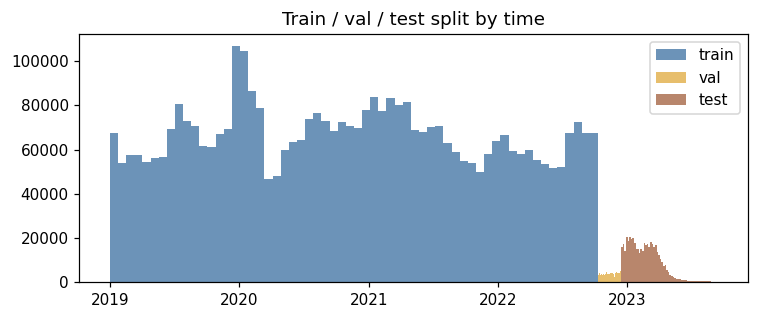

In [11]:
fig, ax = plt.subplots(figsize=(7, 3))
for name, d, color in [("train", train, "#3b6fa0"), ("val", val, "#e0a83b"), ("test", test, "#a05d3b")]:
    ts = pd.to_datetime(d["timestamp"], unit="ms")
    ax.hist(ts, bins=60, label=name, color=color, alpha=0.75)
ax.set_title("Train / val / test split by time"); ax.legend()
plt.tight_layout(); plt.show()

**Positive threshold & item granularity, restated.** `rating >= 4` counts as a "liked"
positive everywhere ground truth is built (`ground_truth_from`, used by every baseline and
retriever's evaluation) — a 3-star review is "fine", not an endorsement, and treating it as
positive would make Recall/NDCG look better than the model actually deserves. Items are keyed
by `parent_asin` (set at streaming time, Section 1) so colour/size variants of one product
don't fragment the catalog or dilute per-item popularity counts.

## 5. Item metadata

Stream metadata only for the items that survived subsampling (`stream_meta` stops early once
every needed id is found) — titles, images, brand, category, price for the webapp's product
cards and the ranker's item-side features.

In [12]:
META_FILE = Path("../rawdata/meta_Electronics_sample.jsonl") if Path("../rawdata").exists() else Path("rawdata/meta_Electronics_sample.jsonl")
t0 = time.time()
# scan_cap=None: the full Electronics metadata file has ~1.6M items total (confirmed by a
# full scan during development) -- stream_meta stops as soon as every needed id is found
# regardless, so this is just a safety ceiling, not an expected scan length.
items = stream_meta(df.item_id.unique(), scan_cap=None,
                     local_file=str(META_FILE) if META_FILE.exists() else None)
print(f"items with metadata: {len(items):,} / {df.item_id.nunique():,}  ({time.time()-t0:.0f}s)")
items.head()

items with metadata: 159,975 / 159,975  (156s)


,item_id,title,image_url,category,brand,price,avg_rating
0,B07SM135LS,Digi-Tatoo Decal Skin Compatible With MacBook ...,https://m.media-amazon.com/images/I/31t4bj9t88...,Decals,Digi-Tatoo,19.99,4.5
1,B089CNGZCW,NotoCity Compatible with Vivoactive 4 band 22m...,https://m.media-amazon.com/images/I/41j56fjX6S...,"Clips, Arm & Wristbands",NotoCity,9.99,4.5
2,B07BJ7ZZL7,"QGHXO Band for Garmin Vivofit 4, Soft Silicone...",https://m.media-amazon.com/images/I/51UefzXMzv...,Arm & Wristband Accessories,QGHXO,14.89,4.4
3,B07Y6MRH7G,KEiiD PC Computer Speaker Compact Bluetooth St...,https://m.media-amazon.com/images/I/31jTMWVT7M...,Computer Speakers,KEiiD,NaN,4.2
4,B07M9421GV,Street Guardian SGGCX2PRO+ Dash Camera with GP...,https://m.media-amazon.com/images/I/31ylfpDpAz...,On-Dash Cameras,Street Guardian,NaN,4.0


## 6. Encode ids

Models never see raw string ids — `encode_ids` (`src/data/load.py`) fits a contiguous
`0..n-1` integer encoder on **train** ids only and adds `u`/`i` columns to all three splits;
a val/test id never seen in train (a genuinely cold user/item) encodes to a trailing `<UNK>`
index rather than crashing. `item_ids` (index → original id) is exactly the ordering
`scripts/export_artifacts.py` later writes to `item_encoder.json`, so the FAISS index and the
API's `idx_map` stay in sync with whatever the retrieval notebooks train.

In [13]:
train, val, test, user_ids, item_ids = encode_ids(train, val, test)
n_users, n_items = len(user_ids), len(item_ids)
print(f"n_users={n_users:,}  n_items={n_items:,}")
cold_val_items = (val["i"] == n_items).mean()
cold_test_items = (test["i"] == n_items).mean()
print(f"cold (unseen-in-train) item rate — val: {cold_val_items:.1%}  test: {cold_test_items:.1%}")

n_users=551,874  n_items=148,172
cold (unseen-in-train) item rate — val: 20.3%  test: 31.1%


## 7. Freeze the split

Everything after this notebook loads `train/val/test/items.parquet` directly rather than
re-running this pipeline — in the real workflow these get copied to Google Drive so a Colab
disconnect doesn't cost a re-run; here they're saved to `../data/`.

In [14]:
DATA = Path("../data") if Path("../data").exists() else Path("data"); DATA.mkdir(exist_ok=True)
train.to_parquet(DATA / "train.parquet")
val.to_parquet(DATA / "val.parquet")
test.to_parquet(DATA / "test.parquet")
items.to_parquet(DATA / "items.parquet")
with open(DATA / "id_encoders.json", "w") as f:
    json.dump({"user_ids": user_ids, "item_ids": item_ids}, f)
print("saved -> data/{train,val,test,items,id_encoders.json}")

saved -> data/{train,val,test,items,id_encoders.json}


## Summary

> **Note:** the table below is from the small local sample this notebook was developed and
> debugged against (`LIMIT=700,000`). It's stale as of the `LIMIT=None` full-scale change
> above — re-running this notebook end-to-end will produce a much larger dataset (up to the
> `MAX_INTERACTIONS=5,000,000` cap) and every number here, plus every downstream notebook's
> results, needs refreshing from the real run's output.

| Stage | Interactions | Users | Items |
|---|---|---|---|
| Raw (post year-filter, small-sample dev run) | 700,000 | 206,051 | 191,340 |
| After 5-core (9 rounds) | 131,154 | 15,266 | 9,671 |
| Train / Val / Test | 111,481 / 6,557 / 13,116 | (train-fit) 15,038 | (train-fit) 9,487 |

Frozen to `data/`. Notebook 02 (baselines) loads these directly.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/amazon-recsys-data'
import os
os.makedirs(DRIVE_DIR, exist_ok=True)


Mounted at /content/drive


In [16]:
!cp -r data artifacts "$DRIVE_DIR/" 2>/dev/null || true
print("synced to Google Drive:", DRIVE_DIR)


synced to Google Drive: /content/drive/MyDrive/amazon-recsys-data
